In this project, we will use Convolutional Neural Network to build train and test a traffic sign classification model. We will build this model using tensorflow and keras. It is a multiclass classification problem. This model can be used to make smarter cars.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

We will start by connecting to Kaggle using Kaggle API which can be downloaded from your Kaggle account's settings and uploading it here(upload box).

In [ ]:
# Run this cell and select the kaggle.json file downloaded from the Kaggle account settings page.
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"lboss1994","key":"48e9a1e1430aacea67db33df8be89829"}'}

Installing kaggle api using pip

In [ ]:
# Next, install the Kaggle API client.
!pip install -q kaggle

Setting up Kaggle using Kaggle API.

In [ ]:
# The Kaggle API client expects this file to be in ~/.kaggle, so move it there.
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/

# This permissions change avoids a warning on Kaggle tool startup.
!chmod 600 ~/.kaggle/kaggle.json

To store the data we will create a new directory and make it as current working directory.

In [ ]:
# Creating directory and changing the current working directory
!mkdir traffic_sign_dataset
%cd traffic_sign_dataset

/content/traffic_sign_dataset


Searching Kaggle for the required dataset using search option(-s) with title **'gtsrb-german-traffic-sign'**. We can also use different search options like searching competitions, notebooks, kernels, datasets, etc.

In [ ]:
# Searching for dataset
!kaggle datasets list -s gtsrb-german-traffic-sign

ref                                                                title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-----------------------------------------------------------------  -------------------------------------------------  -----------  --------------------------  -------------  ---------  ---------------  
meowmeowmeowmeowmeow/gtsrb-german-traffic-sign                     GTSRB - German Traffic Sign Recognition Benchmark    641568792  2018-11-25 18:12:34.427000         177595       1325  0.8235294        
valentynsichkar/traffic-signs-preprocessed                         Traffic Signs Preprocessed                          4471088826  2019-08-31 18:22:11.850000          21354        334  1                
harbhajansingh21/german-traffic-sign-dataset                       German Traffic Sign Dataset                          123621493  2023-07-11 04:21:24.180000           3655         42  1  

After searching the data next step would be downloading the data into collab notebook using references found in search option.

In [ ]:
# Downloading dataset and coming out of directory
!kaggle datasets download meowmeowmeowmeowmeow/gtsrb-german-traffic-sign
%cd ..

Dataset URL: https://www.kaggle.com/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign
License(s): CC0-1.0
100% 612M/612M [00:03<00:00, 162MB/s]

/content


We will unzip the data which is downloaded and remove the irrelevant files.

In [ ]:
# Unzipping downloaded file and removing unusable file
!unzip traffic_sign_dataset/gtsrb-german-traffic-sign.zip -d traffic_sign_dataset
!rm traffic_sign_dataset/gtsrb-german-traffic-sign.zip
!rm -rf traffic_sign_dataset/Meta
!rm -rf traffic_sign_dataset/meta
!rm -rf traffic_sign_dataset/test
!rm -rf traffic_sign_dataset/train
!rm traffic_sign_dataset/Meta.csv

Streaming output truncated to the last 5000 lines.
  inflating: traffic_sign_dataset/train/5/00005_00053_00010.png  
  inflating: traffic_sign_dataset/train/5/00005_00053_00011.png  
  inflating: traffic_sign_dataset/train/5/00005_00053_00012.png  
  inflating: traffic_sign_dataset/train/5/00005_00053_00013.png  
  inflating: traffic_sign_dataset/train/5/00005_00053_00014.png  
  inflating: traffic_sign_dataset/train/5/00005_00053_00015.png  
  inflating: traffic_sign_dataset/train/5/00005_00053_00016.png  
  inflating: traffic_sign_dataset/train/5/00005_00053_00017.png  
  inflating: traffic_sign_dataset/train/5/00005_00053_00018.png  
  inflating: traffic_sign_dataset/train/5/00005_00053_00019.png  
  inflating: traffic_sign_dataset/train/5/00005_00053_00020.png  
  inflating: traffic_sign_dataset/train/5/00005_00053_00021.png  
  inflating: traffic_sign_dataset/train/5/00005_00053_00022.png  
  inflating: traffic_sign_dataset/train/5/00005_00053_00023.png  
  inflating: traffic_sign

Importing required libraries.

In [ ]:
# Importing libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.image import imread
import seaborn as sns
import random
from PIL import Image
from sklearn.model_selection import  train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, Conv2D, MaxPool2D

Visualizing some images of traffic sign from the test dataset. we can see here that the dimension of images are uneven.

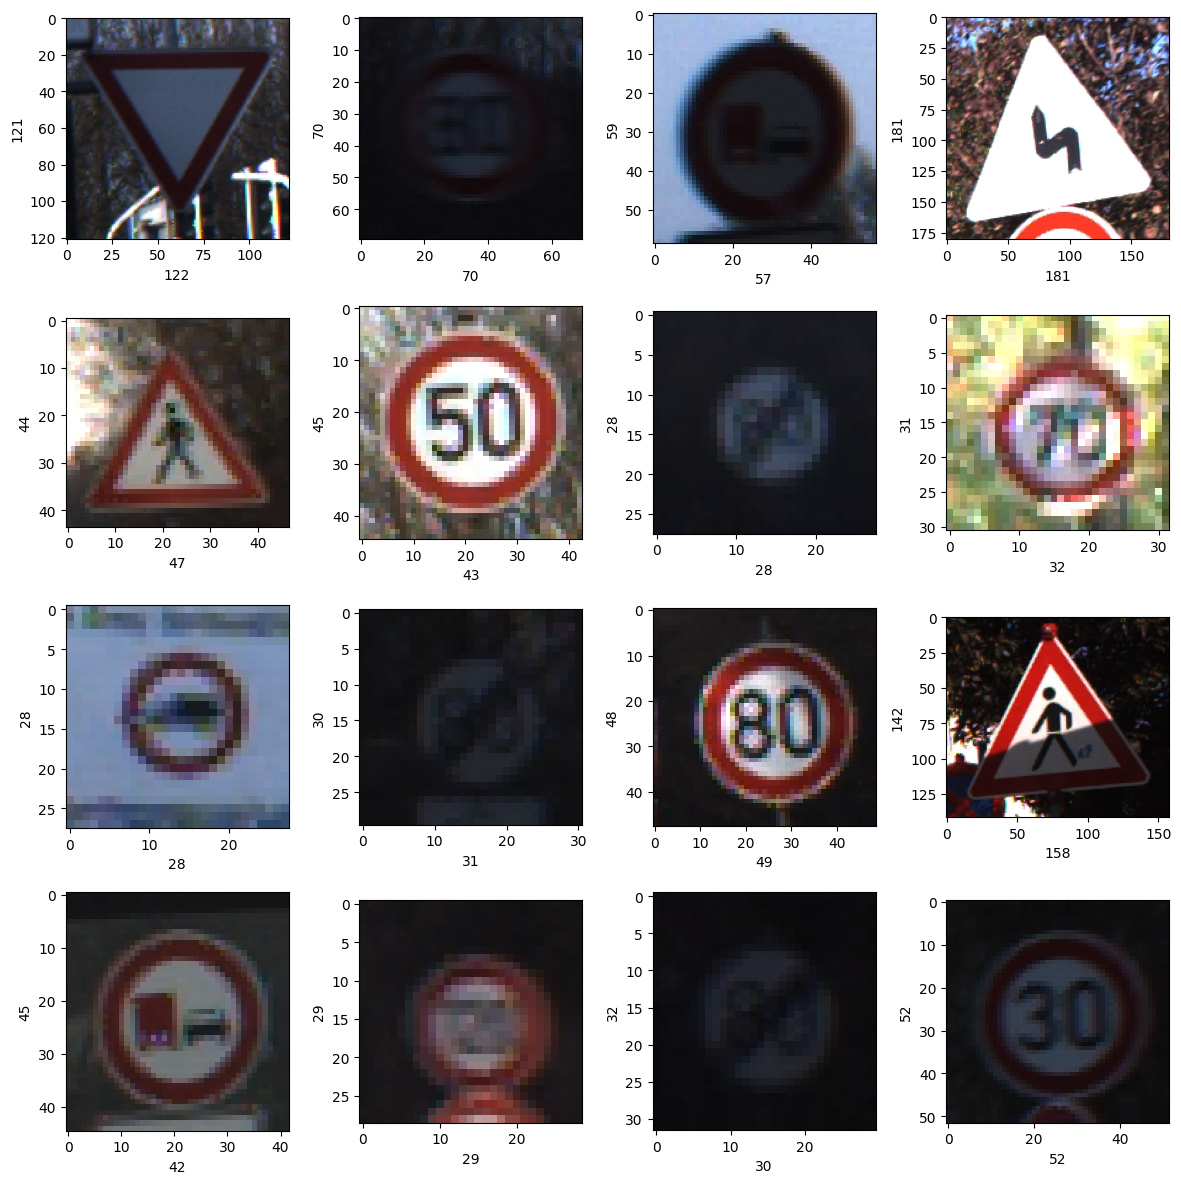

In [ ]:
# Plotting 12 images to check dataset
plt.figure(figsize=(12,12))
path = "traffic_sign_dataset/Test"
for i in range(1,17):
    plt.subplot(4,4,i)
    plt.tight_layout()
    rand_img = imread(path +'/'+ random.choice(sorted(os.listdir(path))))
    plt.imshow(rand_img)
    plt.xlabel(rand_img.shape[1], fontsize = 10)#width of image
    plt.ylabel(rand_img.shape[0], fontsize = 10)#height of image

For further processing we will require the images of same dimension. So, we will start storing the dimension of all the images from training dataset from all 43 classes.  

In [ ]:
# As size of images are different we have to make them equal so we will take mean of dimanesions
dim1 = []
dim2 = []

for i in range(0,43):
    labels = 'traffic_sign_dataset/Train' + '/{0}'.format(i)
    image_path = os.listdir(labels)
    for x in image_path:
        img = imread(labels + '/' + x)
        dim1.append(img.shape[0])
        dim2.append(img.shape[1])

Now we will find out the mean value of both the dimensions and analyse them. Here, we can see that (50,50) is the average shape for all the images.

In [ ]:
#Printing mean dimension of images
print("Dimension 1 Mean : ",np.mean(dim1), " Dimension 2 Mean : ",np.mean(dim2))

Dimension 1 Mean :  50.328929582493814  Dimension 2 Mean :  50.83587951745773


Now we will reshape the images into (50,50) and also store their label ids.

In [ ]:
# Now we will reshape the images to (50,50)
images = []
label_id = []

for i in range(43):
    labels = 'traffic_sign_dataset/Train' + '/{0}'.format(i)
    image_path = os.listdir(labels)
    for x in image_path:
        img = Image.open(labels + '/' + x)
        img = img.resize((50,50))
        img = np.array(img)
        images.append(img)
        label_id.append(i)

Now we will convert all the images into numpy array because CNN requires arrays to perfrom math operations then we normalize them.

In [ ]:
#Converting images into numpy array
images = np.array(images)
#The pixel value of each image ranges between 0 and 255
#Dividing each image by 255 will scale the values between 0 and 1. This is also known as normalization.
images = images/255

Storing the label ids into numpy array and printing the shape. Here we can observe that their are __39209__ label ids.

In [ ]:
label_id = np.array(label_id)
label_id.shape

(39209,)

Checking the shape of the images. Here we can see that their are 39209 images with a shape of (50,50,3.)

In [ ]:
images.shape

(39209, 50, 50, 3)

Now we will observe images per class for checking whether the data is balanced or not. From the result we can say that data is ***balanced***.

In [ ]:
# Visualize the number of classes count
label_counts = pd.DataFrame(label_id).value_counts()
label_counts.head()

,count
0,
2,2250
1,2220
13,2160
12,2100
38,2070


The next step would be to split the data into training and validation with 80% of training data and 20% of validation data.

In [ ]:
#Splitting the data
x_train, x_val, y_train, y_val = train_test_split(images, label_id , test_size = 0.2, random_state = 42)

Defining the model architecture. In this we will define all the layers with their input shape kernel size, activation, etc.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPool2D,
    Dropout,
    Flatten,
    Dense,
    BatchNormalization
)

from tensorflow.keras.optimizers import AdamW
model = tf.keras.Sequential()

# Block 1
model.add(Conv2D(
    filters=64,
    kernel_size=(3,3),
    padding='same',
    activation='relu',
    input_shape=x_train.shape[1:]
))

model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Dropout(0.25))

# Block 2
model.add(Conv2D(
    filters=64,
    kernel_size=(3,3),
    activation='relu'
))

model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Dropout(0.25))

# Dense head
model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(43, activation='softmax'))

#optimizer
optimizer = AdamW(
    learning_rate=0.001,
    weight_decay=1e-4
)


In [ ]:
old_model = tf.keras.models.load_model("model.keras")

Compiling the model using metrics, optimizer and loss as required and printing out the summary of the model.

In [ ]:
model.compile(loss = 'sparse_categorical_crossentropy', optimizer = optimizer, metrics = ['accuracy'])
model.summary()

we will use **learning-Rate Scheduling** to reduces LR automatically when validation loss stops improving.

In [ ]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    verbose=1
)

Now we will fit the model and observe how our is getting trained on each epoch.

In [ ]:
model.fit(x_train, y_train,
          epochs = 10,
          batch_size = 128,
          validation_data = (x_val, y_val),
          callbacks=[lr_scheduler])

Epoch 1/10
246/246 ━━━━━━━━━━━━━━━━━━━━ 433s 2s/step - accuracy: 0.4279 - loss: 2.1048 - val_accuracy: 0.0139 - val_loss: 24.0857 - learning_rate: 0.0010
Epoch 2/10
246/246 ━━━━━━━━━━━━━━━━━━━━ 398s 2s/step - accuracy: 0.7822 - loss: 0.6835 - val_accuracy: 0.4811 - val_loss: 4.5584 - learning_rate: 0.0010
Epoch 3/10
246/246 ━━━━━━━━━━━━━━━━━━━━ 429s 2s/step - accuracy: 0.8880 - loss: 0.3456 - val_accuracy: 0.9675 - val_loss: 0.1071 - learning_rate: 0.0010
Epoch 4/10
246/246 ━━━━━━━━━━━━━━━━━━━━ 414s 2s/step - accuracy: 0.9262 - loss: 0.2286 - val_accuracy: 0.9786 - val_loss: 0.0686 - learning_rate: 0.0010
Epoch 5/10
246/246 ━━━━━━━━━━━━━━━━━━━━ 416s 2s/step - accuracy: 0.9435 - loss: 0.1795 - val_accuracy: 0.9799 - val_loss: 0.0667 - learning_rate: 0.0010
Epoch 6/10
246/246 ━━━━━━━━━━━━━━━━━━━━ 362s 1s/step - accuracy: 0.9504 - loss: 0.1530 - val_accuracy: 0.9864 - val_loss: 0.0447 - learning_rate: 0.0010
Epoch 7/10
246/246 ━━━━━━━━━━━━━━━━━━━━ 417s 2s/step - accuracy: 0.9592 - loss: 0

Next we will visualize the accuracy and loss per epoch. For this we will store the model history in the pandas dataframe and plot them.

<Axes: >

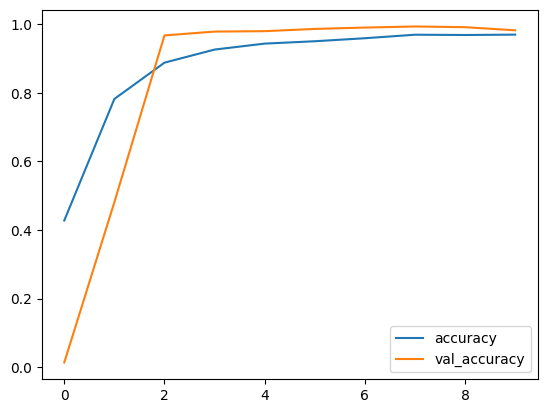

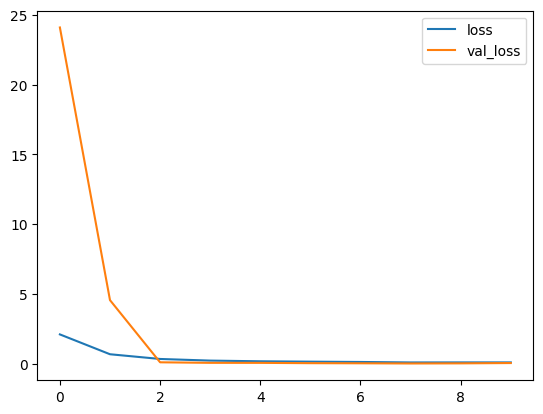

In [ ]:
evaluation = pd.DataFrame(model.history.history)
evaluation[['accuracy', 'val_accuracy']].plot()
evaluation[['loss', 'val_loss']].plot()

Creating the variable which has path of test dataset. As we downloded the dataset we found out that their is a GT-final_test.csv file in the test images folder which cannot be processed. So, we will remove that file.

In [ ]:
test_path = 'traffic_sign_dataset/Test'
!rm traffic_sign_dataset/Test/GT-final_test.csv

Next step would we creating a function to resize the test images converting them into a numpy array and normalize them.

In [ ]:
#defining a function that will scale images
from PIL import Image

def scaling(test_images, test_path):
    images = []

    image_path = test_images

    for x in image_path:
        img = Image.open(test_path + '/' + x)
        img = img.resize((50,50))
        img = np.array(img)
        images.append(img)

    #Converting images into numpy array
    images = np.array(images)
    #The pixel value of each image ranges between 0 and 255
    #Dividing each image by 255 will scale the values between 0 and 1. This is also known as normalization.
    images = images/255

    return images

Calling the above created function on test images.

In [ ]:
test_images = scaling(sorted(os.listdir(test_path)),test_path)

Next we will read label ids from Test.csv and store the values of the class id in y_test variable.

In [ ]:
test = pd.read_csv('traffic_sign_dataset/Test.csv')
y_test = test['ClassId'].values
y_test

array([16,  1, 38, ...,  6,  7, 10])

Now we will use the model to make predictions on our test images and save them in y_pred.

In [ ]:
y_pred = model.predict(test_images);
y_pred_classes = np.argmax(y_pred, axis=1)
y_pred_classes

395/395 ━━━━━━━━━━━━━━━━━━━━ 28s 70ms/step


array([16,  1, 38, ..., 38,  7, 10])

Storing the labels according to the image classes.

In [ ]:
# Storing all lables
all_lables = ['Speed limit (20km/h)','Speed limit (30km/h)','Speed limit (50km/h)','Speed limit (60km/h)',
              'Speed limit (70km/h)','Speed limit (80km/h)','End of speed limit (80km/h)','Speed limit (100km/h)',
              'Speed limit (120km/h)','No passing','No passing for vechiles over 3.5 metric tons',
              'Right-of-way at the next intersection','Priority road','Yield','Stop','No vechiles',
              'Vechiles over 3.5 metric tons prohibited','No entry','General caution','Dangerous curve to the left',
              'Dangerous curve to the right','Double curve','Bumpy road','Slippery road','Road narrows on the right',
              'Road work','Traffic signals','Pedestrians','Children crossing','Bicycles crossing','Beware of ice/snow',
              'Wild animals crossing','End of all speed and passing limits','Turn right ahead','Turn left ahead',
              'Ahead only','Go straight or right','Go straight or left','Keep right','Keep left','Roundabout mandatory',
              'End of no passing','End of no passing by vechiles over 3.5 metric']

Then we create a json file containing all the labels because argmax gives index, not label name.

In [ ]:
import json

with open("class_names.json", "w") as f:
    json.dump(all_lables, f)

Let's visualize test image

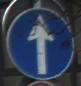

In [ ]:
# Visualize test image
img = Image.open(test_path + '/00009.png')
img

Finding out original label for the image above.

In [ ]:
# Original label
print("Original label : ",all_lables[y_test[9]])

Original label :  Ahead only


Finding out the predicted label for the image above.

In [ ]:
# Predicted label
print("Predicted label : ",all_lables[y_pred_classes[9]])

Predicted label :  Ahead only


Saving the Full Model for production deployment 

In [ ]:
model.save("model.keras")

Saving weights in case we only need to load the model architecture during production deployment

In [ ]:
model.save_weights("traffic.weights.h5")

In [ ]:
model_json = model.to_json()

with open("model_architecture.json", "w") as json_file:
    json_file.write(model_json)

## Conclusion:

We started with downloading the dataset, preprocessing it, created the model and found out the predictions using the model. During preprocessing we found that this dataset has 43 classes. Model reached an accuracy of 96.97%+ in just 10 epochs, we can further optimize the model using hyper parameter tuning and reach a higher accuracy.

# Scope:

This model can be used in self driving cars which will enable them to automatically recognize traffic signs similarly the driver alert system inside cars will help and protect drivers by understanding the traffic signs around them.